# Aggregation visualization: extend → profile → segment → sum

This notebook demonstrates how *point events* that have been **extended** into short
linear events get aggregated onto a **regularly segmented road** using the
`relate` → `overlay(profile=...)` → `sum` process.

The plotting helpers live in [`aggregation_viz.py`](./aggregation_viz.py) and are
fully parameterized, so the same scene can be re-rendered for different extension
distances, segment lengths, and profile shapes.

In [1]:
import sys, os

# Ensure the repo root is importable so `import scripts...` works from anywhere.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from scripts.aggregation_viz import plot_aggregation, compute_aggregation

%matplotlib inline

## Scenario A — single point, triangular profile

A single point at mile `1.0` carrying a value of `1.0` is extended `0.25` mi in each
direction, given a **triangular** value profile (peak at the point, tapering to zero at
the extension edges), and aggregated onto a road segmented every `0.1` mi.

The aggregated per-segment bars sum back to the original value — the process conserves
total value.

per-segment values: [0.   0.02 0.16 0.32 0.32 0.16 0.02 0.  ]
total conserved   : 1.0


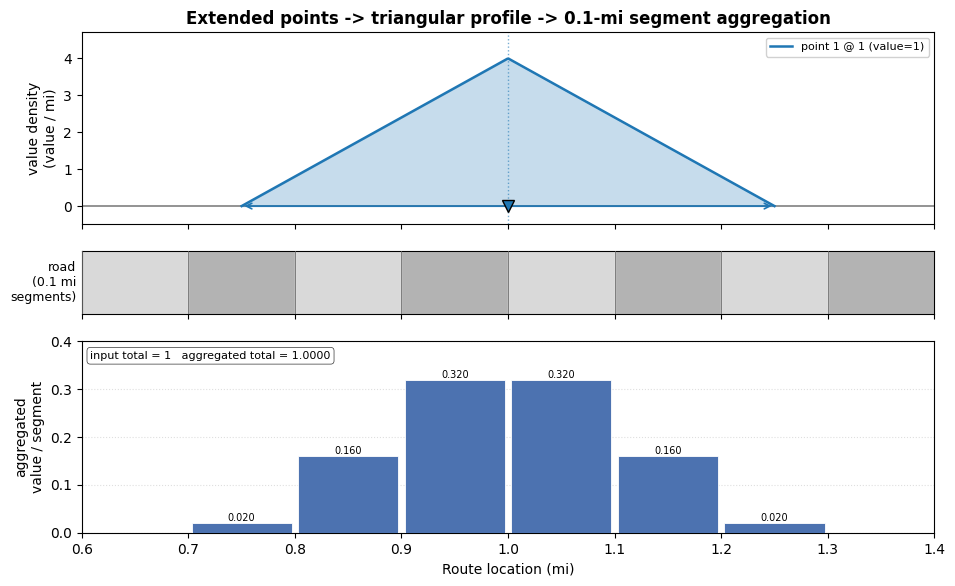

In [2]:
fig, axes, result = plot_aggregation(
    points=[1.0],
    values=[1.0],
    extend=0.25,
    segment_length=0.1,
    profile='triangular',
)

print('per-segment values:', result['seg_values'].round(4))
print('total conserved   :', result['seg_values'].sum())

## Scenario B — two overlapping points, summed

Two points at miles `0.25` and `0.65`, each extended `0.25` mi, overlap in the middle.
Where their extensions overlap, the aggregated segment values are the **sum** of both
points' contributions.

per-segment values: [0.   0.08 0.24 0.36 0.24 0.16 0.24 0.36 0.24 0.08 0.  ]
total conserved   : 2.0


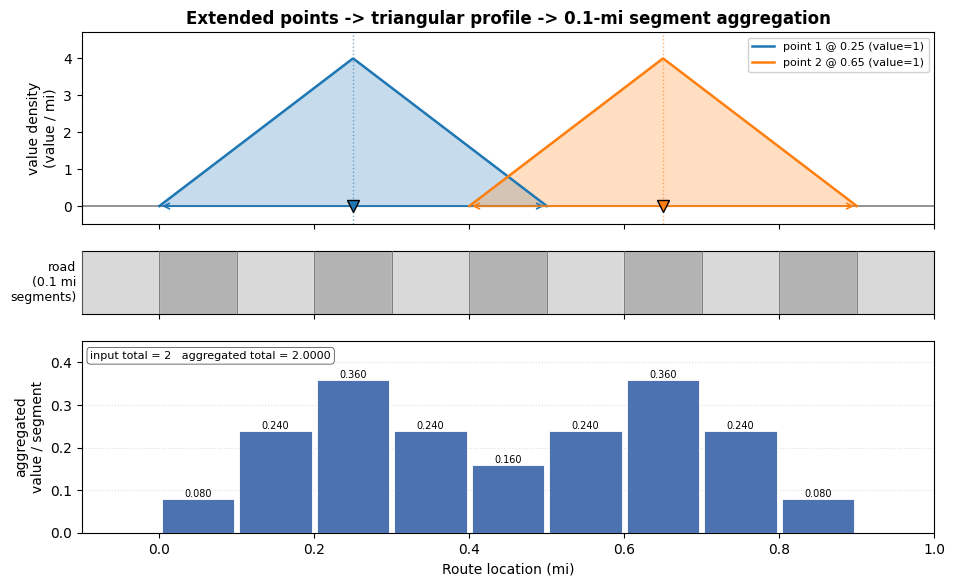

In [19]:
fig, axes, result = plot_aggregation(
    points=[0.25, 0.65],
    values=[1.0, 1.0],
    extend=0.25,
    segment_length=0.1,
    profile='triangular',
)

print('per-segment values:', result['seg_values'].round(4))
print('total conserved   :', result['seg_values'].sum())

## Comparing profile shapes

To compare profiles, re-render the same scene with a different `profile` value. The
built-in options are `'uniform'`, `'triangular'`, `'parabolic'`, and `'trapezoidal'`.

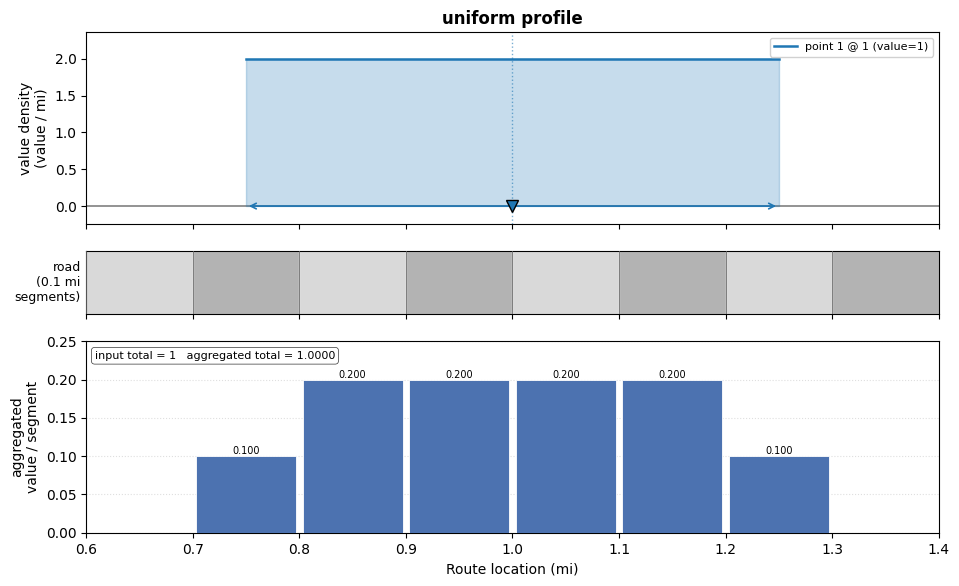

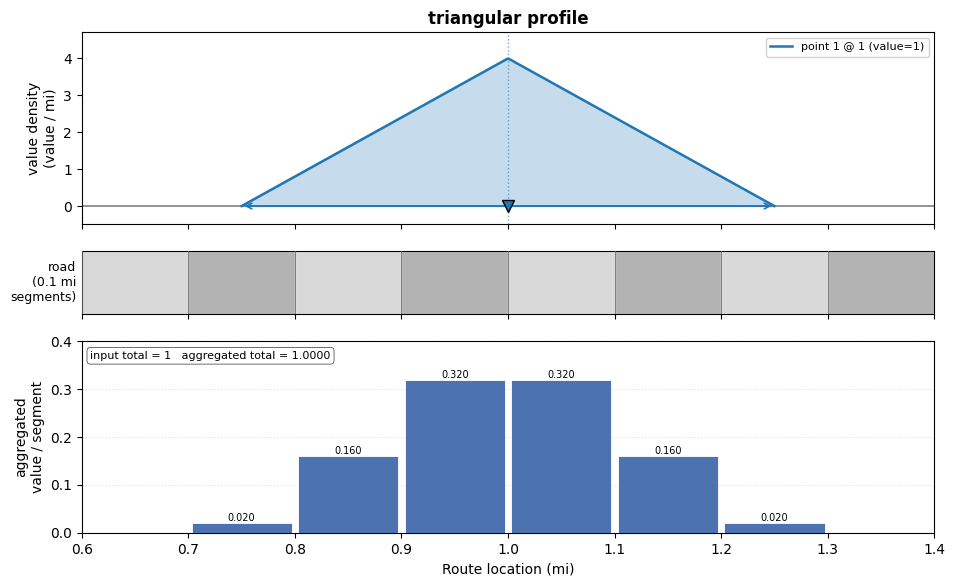

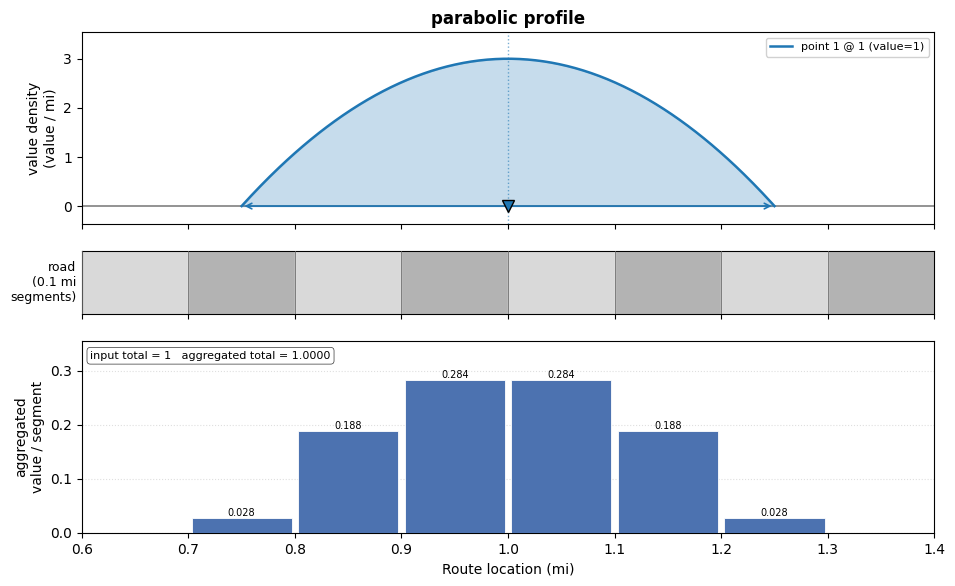

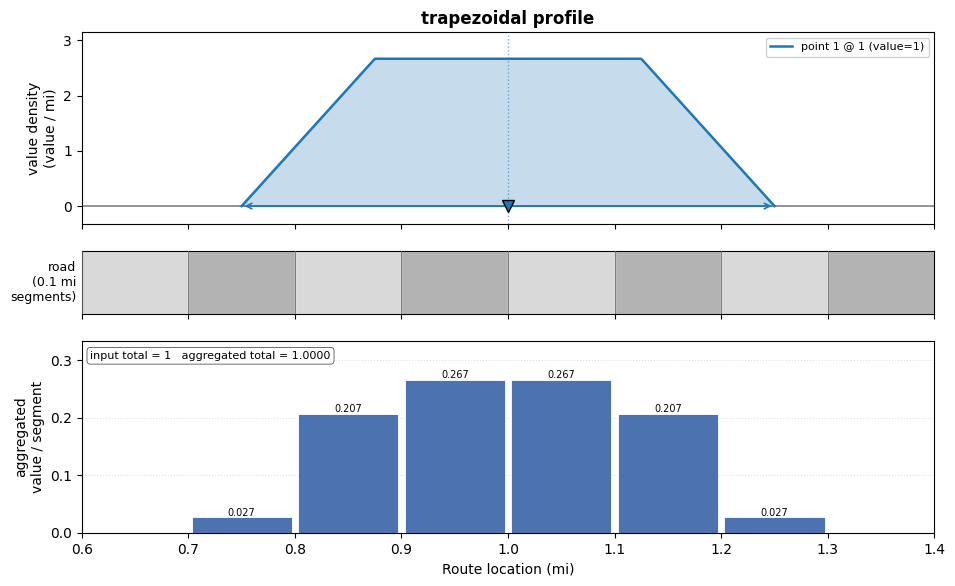

In [4]:
for profile in ['uniform', 'triangular', 'parabolic', 'trapezoidal']:
    plot_aggregation(
        points=[1.0],
        values=[1.0],
        extend=0.25,
        segment_length=0.1,
        profile=profile,
        title=f"{profile} profile",
    )